In [1]:
import cv2
import matplotlib.pyplot as plt
import numpy as np

(720, 720, 3)


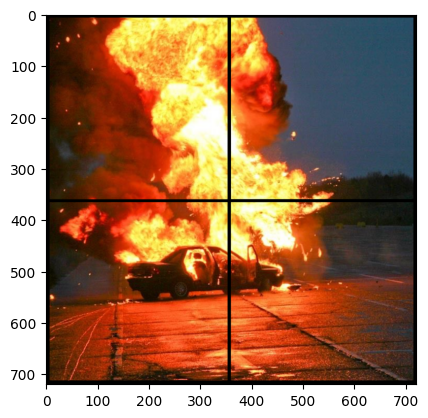

In [13]:
meledak_img = plt.imread("Assets/Meledak.png")
windut_img = cv2.imread("Assets/Windut.png")
bunga_img = cv2.imread("Assets/Bunga.png")
langit_img = cv2.imread("Assets/Langit.png")

plt.imshow(meledak_img)
print(meledak_img.shape)

In [9]:
def slice(image, a, b, mode='H'):
    return image[a:b, :] if mode == 'H' else image[:, a:b]

(340, 720, 3)
(340, 720, 3)


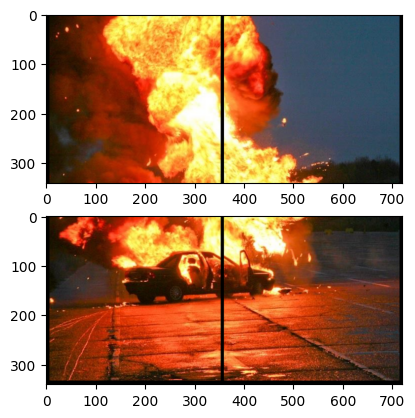

In [42]:
meledak_slice1 = slice(meledak_img, 20, 360, 'H')
meledak_slice2 = slice(meledak_img, 380, 720, 'H')

plt.subplot(2, 1, 1)
plt.imshow(meledak_slice1)
plt.subplot(2, 1, 2)
plt.imshow(meledak_slice2)

print(meledak_slice1.shape)
print(meledak_slice2.shape)

(340, 340, 3)
(340, 340, 3)
(340, 340, 3)
(340, 340, 3)


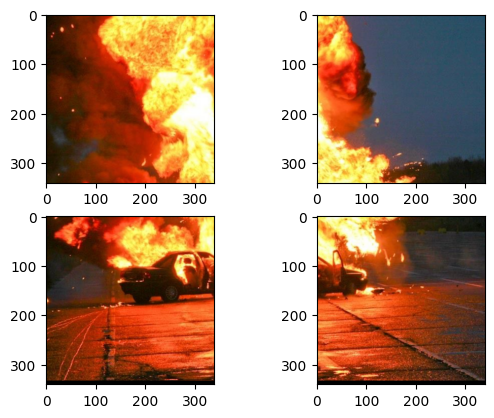

In [ ]:
meledak_slice3 = slice(meledak_slice1, 10, 350, 'V')
meledak_slice4 = slice(meledak_slice1, 360, 700, 'V')
meledak_slice5 = slice(meledak_slice2, 10, 350, 'V')
meledak_slice6 = slice(meledak_slice2, 360, 700, 'V')

plt.subplot(2,2,1)
plt.imshow(meledak_slice3)
plt.subplot(2,2,2)
plt.imshow(meledak_slice4)
plt.subplot(2,2,3)
plt.imshow(meledak_slice5)
plt.subplot(2,2,4)
plt.imshow(meledak_slice6)

print(meledak_slice3.shape)
print(meledak_slice4.shape)
print(meledak_slice5.shape)
print(meledak_slice6.shape)


In [72]:
def merge_image(citra1, citra2, orientation): 
     
    if orientation == 'H':   
        tinggi = max(citra1.shape[0], citra2.shape[0]) 
        lebar_total = citra1.shape[1] + citra2.shape[1] 
         
        if len(citra1.shape) == 2: 
            gabungan = np.zeros((tinggi, lebar_total), dtype=citra1.dtype) 
        else: 
            gabungan = np.zeros((tinggi, lebar_total, citra1.shape[2]), dtype=citra1.dtype) 
         
        gabungan[0:citra1.shape[0], 0:citra1.shape[1]] = citra1 
        gabungan[0:citra2.shape[0], citra1.shape[1]:citra1.shape[1]+citra2.shape[1]] = citra2 
         
    else:   
        tinggi_total = citra1.shape[0] + citra2.shape[0] 
        lebar = max(citra1.shape[1], citra2.shape[1]) 
         
        if len(citra1.shape) == 2: 
            gabungan = np.zeros((tinggi_total, lebar), dtype=citra1.dtype) 
        else: 
            gabungan = np.zeros((tinggi_total, lebar, citra1.shape[2]), dtype=citra1.dtype) 
         
        gabungan[0:citra1.shape[0], 0:citra1.shape[1]] = citra1 
        gabungan[citra1.shape[0]:citra1.shape[0]+citra2.shape[0], 0:citra2.shape[1]] = citra2 
     
    return gabungan

(680, 340, 3)
(680, 340, 3)


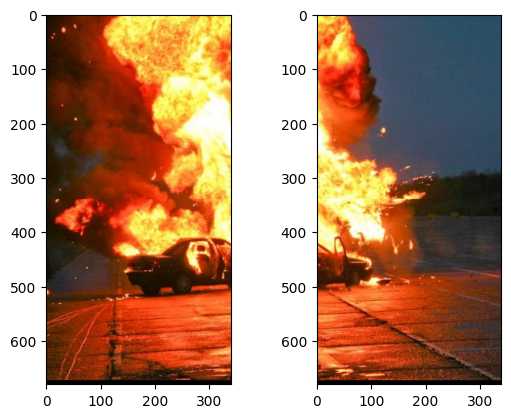

In [73]:
merge35 = merge_image(meledak_slice3, meledak_slice5, 'V')
merge46 = merge_image(meledak_slice4, meledak_slice6, 'V')

plt.subplot(1, 2, 1)
plt.imshow(merge35)
plt.subplot(1, 2, 2)
plt.imshow(merge46)

print(merge35.shape)
print(merge46.shape)

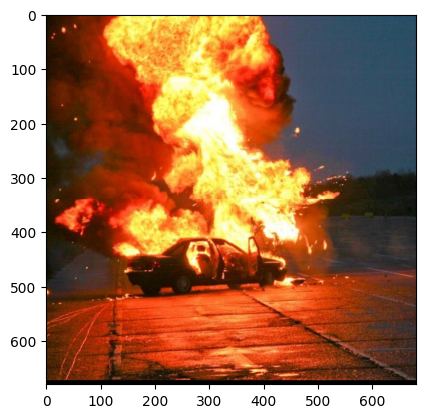

In [76]:
merge3546 = merge_image(merge35, merge46, 'H')
plt.imshow(merge3546)

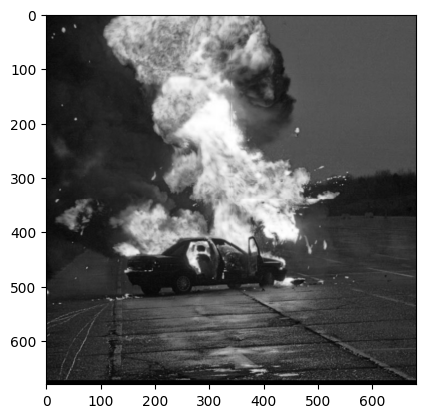

In [112]:
meledak_gray = cv2.cvtColor(merge3546, cv2.COLOR_BGR2GRAY)
windut_gray = cv2.cvtColor(windut_img, cv2.COLOR_BGR2GRAY)
bunga_gray = cv2.cvtColor(bunga_img, cv2.COLOR_BGR2GRAY)
langit_gray = cv2.cvtColor(langit_img, cv2.COLOR_BGR2GRAY)

plt.imshow(meledak_gray, cmap='gray')

In [107]:
def normalize_min_max(image):
    min_val = np.min(image)
    max_val = np.max(image)
    if max_val == min_val:
        return np.zeros_like(image, dtype=np.uint8) 
    norm = (image - min_val) / (max_val - min_val)
    return (norm * 255).astype(np.uint8)

In [108]:
meledak_gray_norm = normalize_min_max(meledak_gray)

In [104]:
def histogram_equalization(image):
    e_hist = np.zeros(256, dtype=int)
    height, width = image.shape

    for i in range(height):
        for j in range(width):
            val = int(image[i, j])
            e_hist[val] += 1

    cdf = np.zeros(256, dtype=int)
    for i in range(256):
        cdf[i] = np.sum(e_hist[0:i+1])

    result = np.round((cdf * 255) / (height * width)).astype(np.uint8)

    result2 = np.zeros(image.shape, dtype=np.uint8)
    for i in range(height):
        for j in range(width):
            val = int(image[i, j])
            result2[i, j] = result[val]

    return result2

In [101]:
def buat_hist(citra): 
    histogram = [0] * 256 
 
    height = len(citra) 
    width = len(citra[0]) if height > 0 else 0 
    for i in range(height): 
        for j in range(width): 
            val = int(citra[i][j])   
            histogram[val] += 1   
 
    return histogram 

def plot_histogram(histogram, title, ImgColor): 
    plt.figure(figsize=(10, 5)) 
    plt.xlabel("Intensitas Piksel") 
    plt.title(title) 
    plt.ylabel("Jumlah Piksel") 
    plt.bar(range(256), histogram, color=ImgColor, width=0.8) 
    plt.show() 

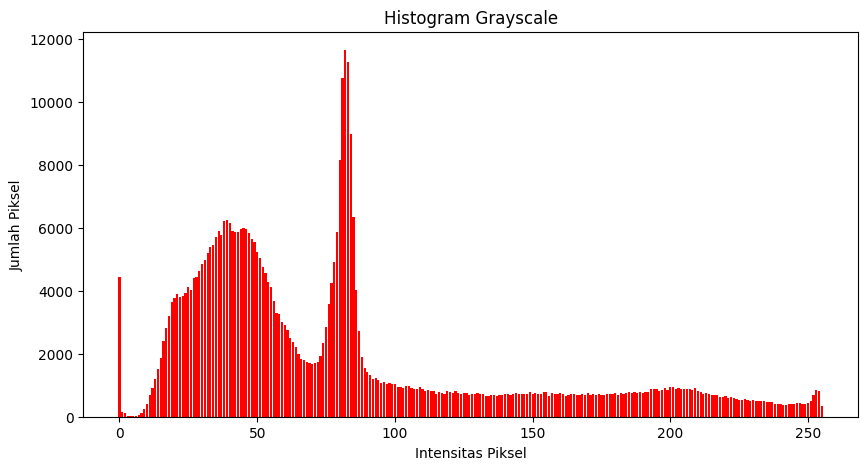

In [109]:
meledak_gray_hist = buat_hist(meledak_gray_norm)
meledak_gray_plot = plot_histogram(meledak_gray_hist, "Histogram Grayscale", "Red")


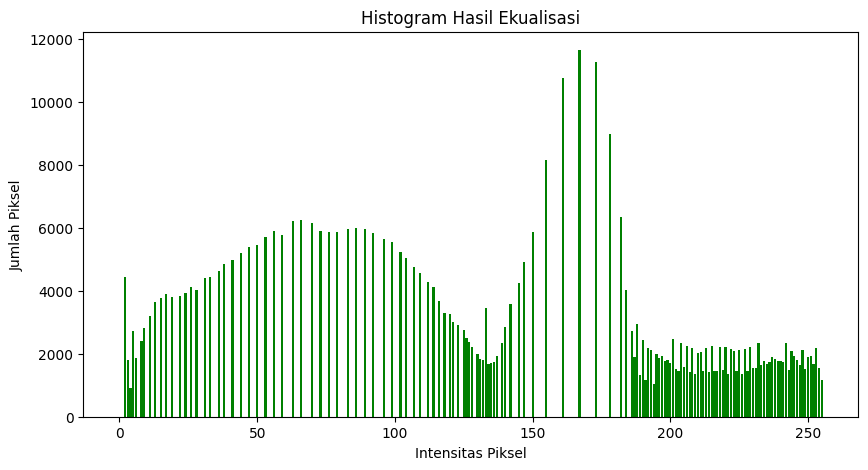

In [110]:
meledak_ekual = histogram_equalization(meledak_gray_norm)
meledak_ekual_hist = buat_hist(meledak_ekual)
meledak_ekual_plot = plot_histogram(meledak_ekual_hist, "Histogram Hasil Ekualisasi", "Green")

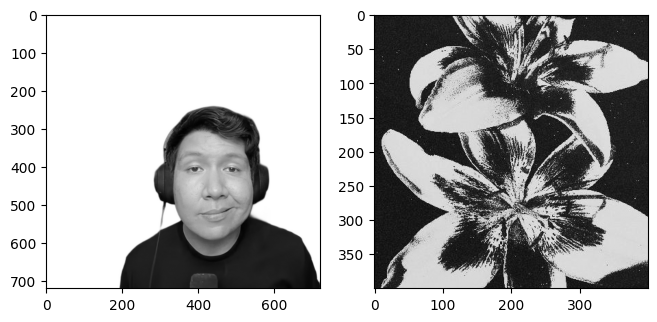

In [121]:
plt.figure(figsize=(12,8))

plt.subplot(1, 3, 1)
plt.imshow(windut_gray, cmap='gray')
plt.subplot(1, 3, 2)
plt.imshow(bunga_gray, cmap='gray')

In [122]:
windut_norm = normalize_min_max(windut_gray)
bunga_norm = normalize_min_max(bunga_gray)

In [123]:
windut_ekual = histogram_equalization(windut_norm)
bunga_ekual = histogram_equalization(bunga_norm)

In [124]:
def histogram_specification(source, target):
    height, width = source.shape

    # Hitung histogram source
    hist_source = np.zeros(256, dtype=int)
    for i in range(height):
        for j in range(width):
            hist_source[source[i, j]] += 1
    cdf_source = np.cumsum(hist_source)
    cdf_source = np.round(cdf_source * 255 / cdf_source[-1]).astype(np.uint8)

    # Hitung histogram target
    hist_target = np.zeros(256, dtype=int)
    for i in range(target.shape[0]):
        for j in range(target.shape[1]):
            hist_target[target[i, j]] += 1
    cdf_target = np.cumsum(hist_target)
    cdf_target = np.round(cdf_target * 255 / cdf_target[-1]).astype(np.uint8)

    # Buat mapping dari CDF source ke CDF target
    mapping = np.zeros(256, dtype=np.uint8)
    for source_val in range(256):
        diff = np.abs(cdf_source[source_val] - cdf_target)
        mapping[source_val] = np.argmin(diff)

    # Terapkan mapping ke gambar source
    result = np.zeros_like(source)
    for i in range(height):
        for j in range(width):
            result[i, j] = mapping[source[i, j]]

    return result

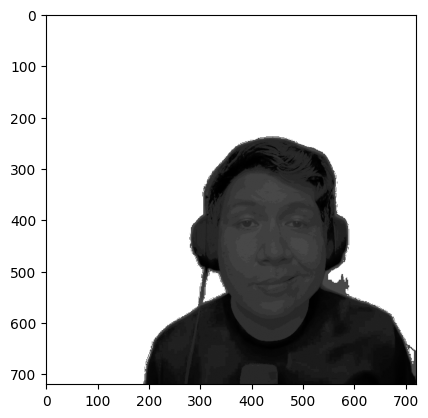

In [128]:
windut_spec = histogram_specification(windut_ekual, bunga_ekual)

plt.imshow(windut_spec, cmap='gray')

In [129]:
def thresholding(image, angka):
    h, w = image.shape
    hasil = np.zeros((h,w), dtype=image.dtype)
    
    for x in range(h):
        for y in range(w):
            if(image[x,y] >= angka):
                hasil[x,y] = 255
            else:
                hasil[x,y] = 0
    return hasil

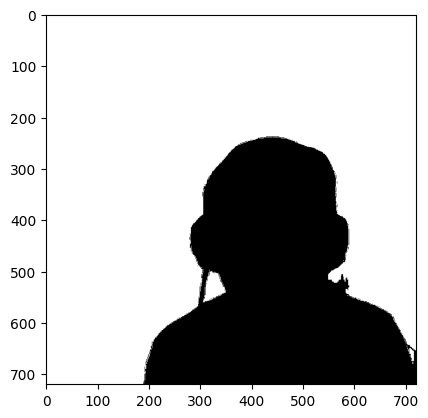

In [136]:
windut_thresholding = thresholding(windut_spec, 135)

plt.imshow(windut_thresholding, cmap='gray')

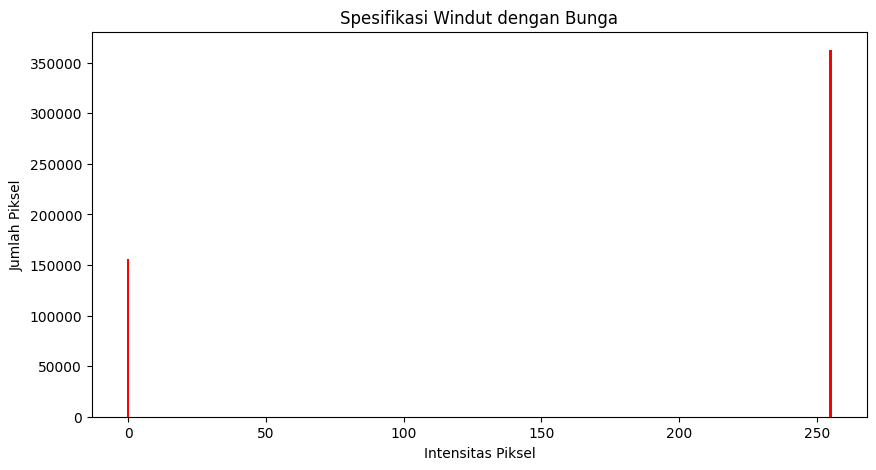

In [137]:
windut_thres_hist = buat_hist(windut_thresholding)
windut_thres_plot = plot_histogram(windut_thres_hist, "Spesifikasi Windut dengan Bunga", "Red")

(680, 680)
(720, 720)


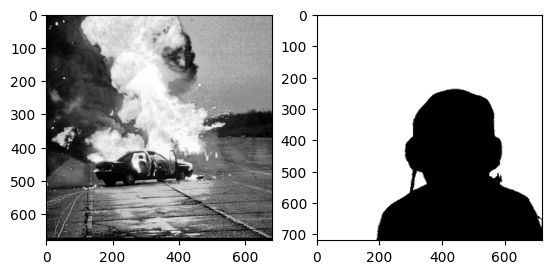

In [138]:
plt.subplot(1,2,1)
plt.imshow(meledak_ekual, cmap='gray')
plt.subplot(1,2,2)
plt.imshow(windut_thresholding, cmap='gray')

print(meledak_ekual.shape)
print(windut_thresholding.shape)

(680, 680)
(680, 680)


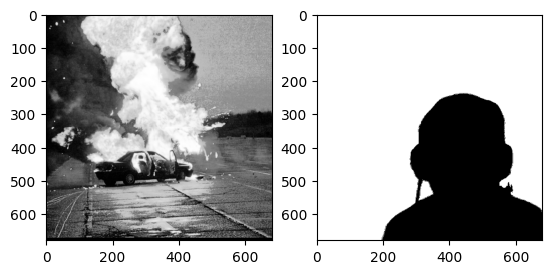

In [149]:
windut_crop = windut_thresholding[0:680, 0:680]

plt.subplot(1,2,1)
plt.imshow(meledak_ekual, cmap='gray')
plt.subplot(1,2,2)
plt.imshow(windut_crop, cmap='gray')

print(meledak_ekual.shape)
print(windut_crop.shape)

In [164]:
def stack_with_mask(background, foreground, mask):
    h, w = background.shape
    hasil = background.copy()
    
    for i in range(h):
        for j in range(w):
            if mask[i, j] == 255: #
                hasil[i, j] = foreground[i, j]
    return hasil

In [174]:
print(windut_gray.shape)

windut_crop2 = windut_gray[0:680, 0:680]
print(windut_crop2.shape)


(720, 720)
(680, 680)


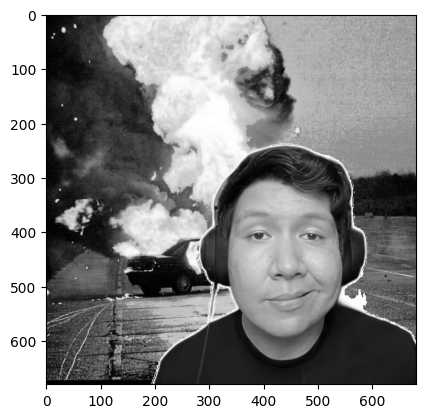

In [181]:
windut_meledak = stack_with_mask(windut_crop2, meledak_ekual, windut_crop)
plt.imshow(windut_meledak, cmap='gray')

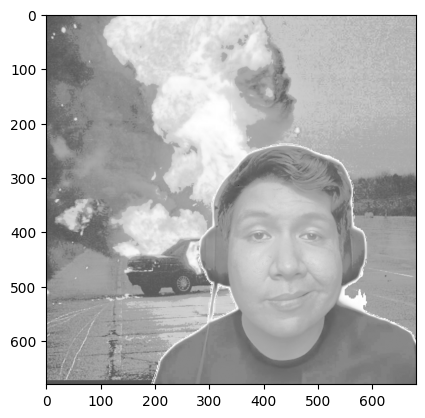

In [182]:
windut_spec_akhir = histogram_specification(windut_meledak, langit_gray)
plt.imshow(windut_spec_akhir, cmap='gray')